# LLM expert persona eval analysis

## 🛢️ Data preparation

- Multiple prompt versions have been used to obtain results, but this notebook will only analyse data from the current prompt version.
- The program used to obtain the results has the option to retry parse failures, meaning total parse failures and unique parse failures may be different.
- Sometimes a parse failure occurs for a question under one conditon but not another. To keep things fair, both questions are removed in this case.

In [1]:
import pandas as pd
from IPython.display import Markdown, display

df = pd.read_json('results.jsonl', lines=True)

# prompt version
current_prompt_version = 'question_v2'
current_prompt_df = df[df['prompt']==current_prompt_version]

print(f'\n\nTotal rows: {len(df)}')
print(f'Total rows for the current prompt version: {len(current_prompt_df)}\n')

display(Markdown('*-- from here all metrics refer to data for the current prompt only --*'))

# parse failures
parse_failures = len(current_prompt_df[current_prompt_df['result']=='parse_failure'])
unique_parse_failures = len(current_prompt_df[current_prompt_df['result']=='parse_failure']['question'].unique())
parse_failure_questions = current_prompt_df[current_prompt_df['result']=='parse_failure']['question'].unique()
filtered_df = current_prompt_df[~current_prompt_df['question'].isin(parse_failure_questions)]
filtered_df.reset_index(inplace=True)
usable_rows = len(filtered_df)
usable_rows_per_condition = len(filtered_df[filtered_df['is_expert']==True])

print(f'\nTotal parse failures: {parse_failures}')
print(f'Total unique parse failures: {unique_parse_failures}')
print(f'Rows removed due to parse failures: {len(current_prompt_df) - usable_rows}')
print(f'Total usable rows: {usable_rows}')
print(f'Total usable rows per condition: {usable_rows_per_condition}\n\n')

filtered_df.head()



Total rows: 809
Total rows for the current prompt version: 805



*-- from here all metrics refer to data for the current prompt only --*


Total parse failures: 5
Total unique parse failures: 5
Rows removed due to parse failures: 8
Total usable rows: 797
Total usable rows per condition: 398




,index,result,category,is_expert,question,correct_answer,llm_answer,asked_at,prompt,model
0,4,fail,math,True,Use divergence therem to evaluate $\iint_S \ve...,I,(B),2026-06-30 16:57:26+00:00,question_v2,gemini-2.5-flash-lite
1,5,pass,law,True,"A buyer contracted in writing to purchase 1,00...",A,(A),2026-06-30 16:57:41+00:00,question_v2,gemini-2.5-flash-lite
2,6,fail,business,True,"Suppose there are 8,000 hours in a year (actua...",G,(C),2026-06-30 16:59:29+00:00,question_v2,gemini-2.5-flash-lite
3,7,pass,computer science,True,"Let a undirected graph G with edges E = {<0,1>...",H,(H),2026-06-30 16:59:45+00:00,question_v2,gemini-2.5-flash-lite
4,8,pass,math,True,What is the value of p in 24 = 2p?,H,(H),2026-06-30 17:00:01+00:00,question_v2,gemini-2.5-flash-lite


## 📊 Descriptive statistics


Control pass rate: 47.12%
Expert pass rate: 49.5%



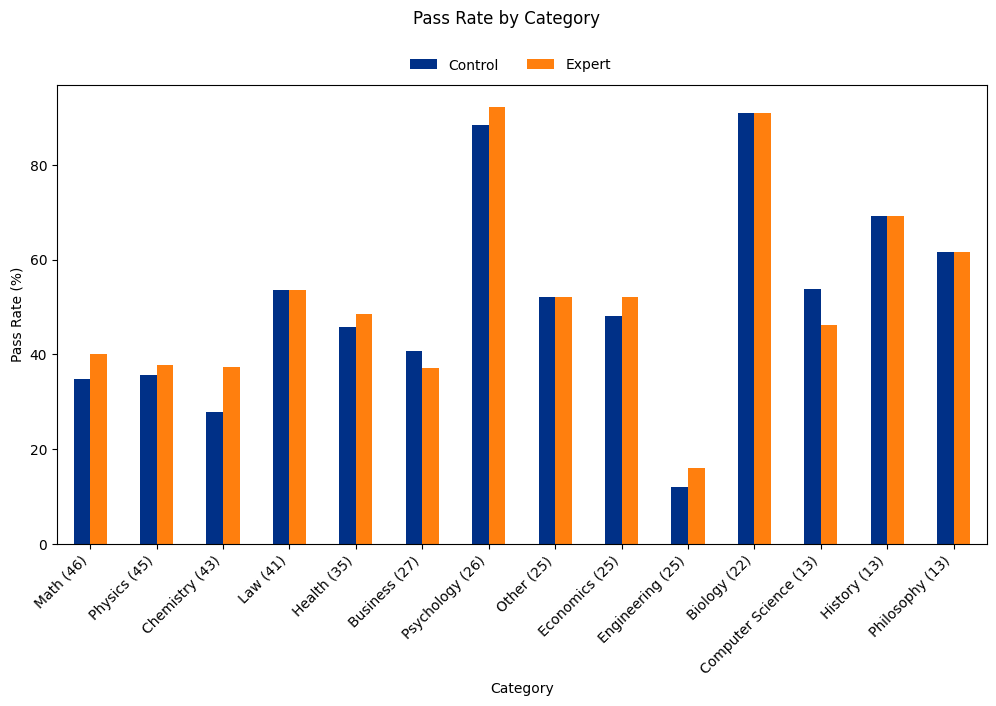

In [11]:
import matplotlib.pyplot as plt

# overall pass rate
control_pass_rate = round(float((filtered_df[filtered_df['is_expert']==False]['result']=='pass').mean()) * 100, 2)
expert_pass_rate = round(float((filtered_df[filtered_df['is_expert']==True]['result']=='pass').mean()) * 100, 2)

print(f'\nControl pass rate: {control_pass_rate}%')
print(f'Expert pass rate: {expert_pass_rate}%\n')


# pass rate by category vizz
category_counts = (
    filtered_df.groupby('category')['question']
    .nunique()
)

pass_rate = (
    (filtered_df['result'] == 'pass')
    .groupby([filtered_df['category'], filtered_df['is_expert']])
    .mean()
    * 100
)

plot_df = pass_rate.unstack()

plot_df = plot_df.rename(columns={False: 'Control', True: 'Expert'})

ordered_categories = category_counts.sort_values(ascending=False).index
plot_df = plot_df.loc[ordered_categories]

formatted_names = {
    cat: cat.replace('_', ' ').replace('-', ' ').title()
    for cat in plot_df.index
}

plot_df.index = [
    f'{formatted_names[cat]} ({int(category_counts[cat])})'
    for cat in plot_df.index
]

fig, ax = plt.subplots(figsize=(12, 6))

plot_df.plot(kind='bar', ax=ax, color=['#003087', '#FF7F0E'])

ax.set_ylabel('Pass Rate (%)')
ax.set_xlabel('Category')

fig.suptitle('Pass Rate by Category', y=1)

ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.4875, 1),
    ncol=len(plot_df.columns),
    frameon=False
)

plt.xticks(rotation=45, ha='right')

plt.subplots_adjust(top=0.875)

plt.show()

## 🔬 Inferential statistics

### McNemar's test

#### Built-in Implementation

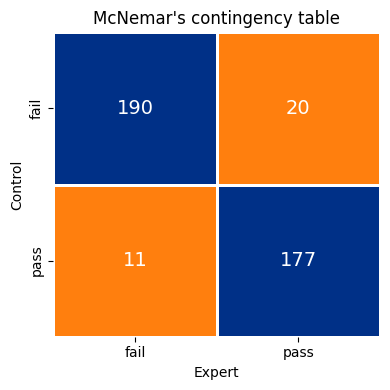


p-value: 0.14961278438568115 



In [3]:
from statsmodels.stats.contingency_tables import mcnemar
from matplotlib.colors import ListedColormap
import seaborn as sns

paired = filtered_df.pivot(
    index='question',
    columns='is_expert',
    values='result'
)

paired.columns = ['Control', 'Expert']

paired = paired.reset_index()

table = pd.crosstab(
    paired['Control'],
    paired['Expert']
)

cmap = ListedColormap([
    '#FF7F0E',
    '#003087'
])

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap=cmap,
    cbar=False,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 14},
    ax=ax
)
ax.set_xlabel('Expert')
ax.set_ylabel('Control')
ax.set_title("McNemar's contingency table")
plt.tight_layout()
plt.show()

result = mcnemar(table, exact=True)

print('\np-value:', result.pvalue, '\n')

#### Manual implementation

In [4]:
b = table.iloc[0, 1]
c = table.iloc[1, 0]
n = b + c
p = 0.5

verbose=True

def comb(n, k):
    if k > n:
        return 0

    k = min(k, n - k)
    result = 1
    
    for i in range(1, k + 1):
        if verbose:
            print(f'comb calc {i}/{k}: result = {result} * ({n} - {k} + {i}) // {i}')
            
        result = result * (n - k + i) // i
        
    return result

def binom_pmf(k, n, p):
    if verbose:
        print(f'\nbinom_pmf calc: comb({n}, {k}) * ({p}**{k}) * ((1-{p})**({n}-{k}))')
        
    return comb(n, k) * (p**k) * ((1-p)**(n-k))

x = min(b, c)

x_binom_pmf = binom_pmf(x, n, p)

print(f'x_binom_pmf = {x_binom_pmf}')

p_value = 0

for k in range(0, n + 1):
    k_binom_pmf = binom_pmf(k, n, p)

    addition = 0

    if k_binom_pmf <= x_binom_pmf:
        addition = k_binom_pmf
    
    if verbose:
        print(f'p-value calc {k+1}/{n + 1}: p-value = {p_value} + {addition}')
        
    p_value += addition

print('\n\np-value:', p_value)


binom_pmf calc: comb(31, 11) * (0.5**11) * ((1-0.5)**(31-11))
comb calc 1/11: result = 1 * (31 - 11 + 1) // 1
comb calc 2/11: result = 21 * (31 - 11 + 2) // 2
comb calc 3/11: result = 231 * (31 - 11 + 3) // 3
comb calc 4/11: result = 1771 * (31 - 11 + 4) // 4
comb calc 5/11: result = 10626 * (31 - 11 + 5) // 5
comb calc 6/11: result = 53130 * (31 - 11 + 6) // 6
comb calc 7/11: result = 230230 * (31 - 11 + 7) // 7
comb calc 8/11: result = 888030 * (31 - 11 + 8) // 8
comb calc 9/11: result = 3108105 * (31 - 11 + 9) // 9
comb calc 10/11: result = 10015005 * (31 - 11 + 10) // 10
comb calc 11/11: result = 30045015 * (31 - 11 + 11) // 11
x_binom_pmf = 0.0394286192022264

binom_pmf calc: comb(31, 0) * (0.5**0) * ((1-0.5)**(31-0))
p-value calc 1/32: p-value = 0 + 4.656612873077393e-10

binom_pmf calc: comb(31, 1) * (0.5**1) * ((1-0.5)**(31-1))
comb calc 1/1: result = 1 * (31 - 1 + 1) // 1
p-value calc 2/32: p-value = 4.656612873077393e-10 + 1.4435499906539917e-08

binom_pmf calc: comb(31, 2) 